In [4]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from custom_kfold import CustomKFold
from sdee_statistics import calculate_nmae
from train_dataset import get_X_y, train_model_cv
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import (
    SelectPercentile,
    f_regression,
    mutual_info_regression,
)
from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.feature_selection import mutual_info_regression



In [5]:
# load dataset heads:
dataset_iteration_30 = pd.read_csv("datasets/apache_iteration_30_features.csv")
dataset_iteration_30.head(1)

# setup model:
X, y = get_X_y(dataset_iteration_30)

custom_kfold = CustomKFold(n_splits=10, shuffle=False)

# train model
random_forest = RandomForestRegressor(n_estimators=500, max_depth=7, random_state=42)

nmae_scorer = make_scorer(calculate_nmae, greater_is_better=False)

In [6]:
#nmae_values = train_model_cv(X, y, random_forest, custom_kfold)
nmae_values = cross_val_score(random_forest, X, y, cv=custom_kfold, scoring=nmae_scorer) 
print(f"Avg nmae: {sum(nmae_values) / len(nmae_values)}")

Avg nmae: -0.3321543077356952


### Feature importances

nº features: 97


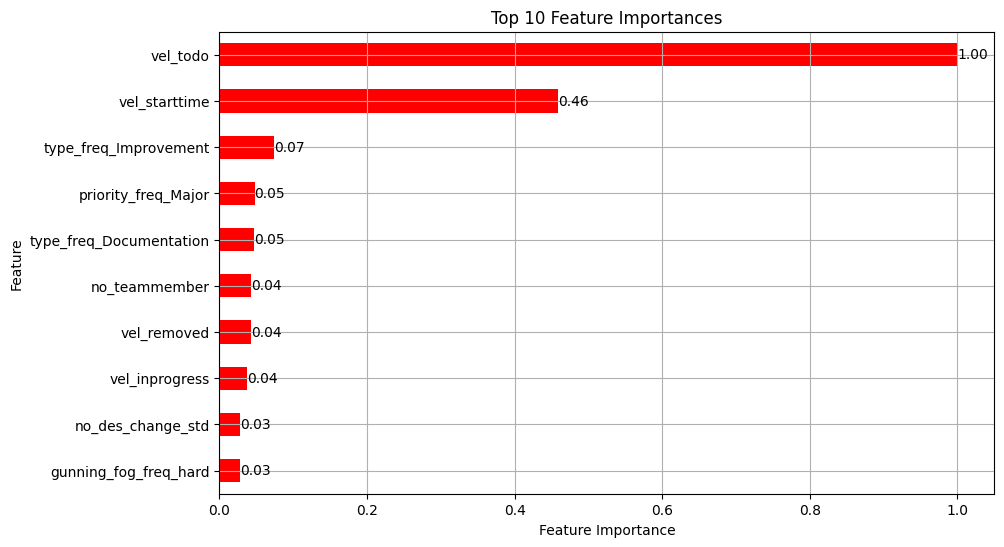

In [7]:
def get_feature_importances(random_forest, X):
    return pd.Series(random_forest.feature_importances_, index=X.columns)


def scale_features(feature_importance_series):
    scaler = MinMaxScaler()
    feature_importances_normalized = scaler.fit_transform(
        feature_importance_series.values.reshape(-1, 1)
    ).flatten()
    feature_importances_normalized = pd.Series(
        feature_importances_normalized, index=feature_importance_series.index
    )
    return feature_importances_normalized


def plot_feature_importances(feature_importances, top_n=10):
    feature_importances = feature_importances.sort_values(ascending=False)[:top_n]

    plt.figure(figsize=(10, 6))
    plt.title("Top 10 Feature Importances")
    feature_importances.plot(kind="barh", color="r")
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    plt.grid()
    plt.gca().invert_yaxis()  # Invert y-axis to have the most relevant feature at the top
    # Annotate each bar with its value
    for i, value in enumerate(feature_importances):
        plt.text(value, i, f"{value:.2f}", ha="left", va="center")
    plt.show()


random_forest.fit(X, y)
print(f"nº features: {len(random_forest.feature_importances_)}")
# get the feature ranking of the rf model:
feature_importances = get_feature_importances(random_forest, X)

feature_importances_normalized = scale_features(feature_importances)
plot_feature_importances(feature_importances_normalized)

### Try if Features subset reduces NMAE

In [20]:
# Evaluate the model with NMAE
X, y = get_X_y(dataset_iteration_30)

def custom_scorer(X, y):
    random_forest.fit(X, y)
    return random_forest.feature_importances_

percentiles = [20, 40, 60]
for percentile in percentiles:
    print(f"Training model for {percentile}% of the features:")
    pipeline = Pipeline(
        [
            (
                "feature_selection",
                SelectPercentile(
                    percentile=percentile, score_func=custom_scorer
                ),
            ),
            ("regressor", random_forest),
        ]
    )

    nmae_values = cross_val_score(pipeline, X, y, cv=custom_kfold, scoring=nmae_scorer)
    print(f"avg nmae: {sum(nmae_values) / len(nmae_values)}")
    print("=" * 40)

Training model for 20% of the features:
avg nmae: -0.33001028439571656
Training model for 40% of the features:
avg nmae: -0.33005096459240013
Training model for 60% of the features:
avg nmae: -0.3301358477777019


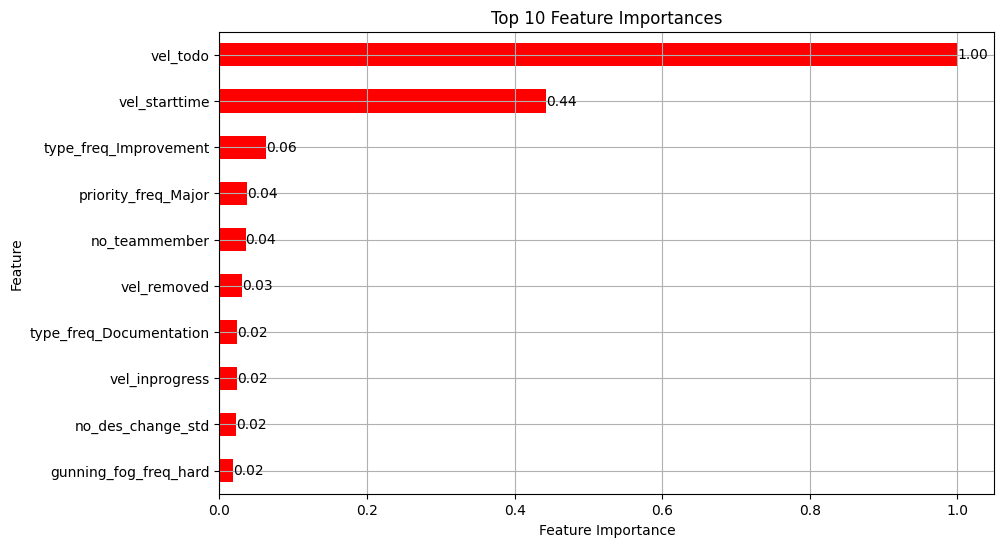

In [9]:
# result of features:
pipeline.fit(X,y)
selected_feature_indices = pipeline.named_steps["feature_selection"].get_support(
    indices=True
)
feature_importances=pipeline.named_steps["regressor"].feature_importances_

feature_importance_dict = {}

for index, importance in zip(selected_feature_indices, feature_importances):
    feature_name = X.columns[index]
    feature_importance_dict[feature_name] = importance

feature_importances = pd.Series(feature_importance_dict)

feature_importances_normalized = scale_features(feature_importances)

plot_feature_importances(feature_importances_normalized)

### Sequential Forward Search

In [12]:
sfs = SequentialFeatureSelector(
    RandomForestRegressor(n_estimators=500, max_depth=7, random_state=42),
    n_features_to_select=0.2,
    cv=custom_kfold,
    n_jobs=-1,
    scoring=make_scorer(calculate_nmae, greater_is_better=False),
)

sfs.fit(X, y)
print(sfs.get_support())

[False  True False False  True False False False False False False False
 False False False  True False False False False False False False False
 False False  True False False False False False False False False False
  True False False False False False False False False False False False
 False False False False False False False False False False False False
 False  True False  True  True False False False  True  True False False
 False False  True  True False  True  True False False False False False
 False  True  True  True  True False False False False False False  True
 False]


In [19]:
selected_feature_indices = sfs.get_support()
feature_names = X.columns[selected_feature_indices]
print(feature_names)

reduced_features_X = sfs.transform(X)
nmae_values = cross_val_score(RandomForestRegressor(n_estimators=500, max_depth=7, random_state=42), reduced_features_X, y, cv=custom_kfold, scoring=nmae_scorer)
print(f"avg nmae: {sum(nmae_values) / len(nmae_values)}")
print("=" * 40)

Index(['vel_starttime', 'no_issue_removed', 'type_freq_Improvement',
       'no_affectversion_min', 'no_fixversion_median',
       'no_fixversion_change_min', 'no_fixversion_change_mean',
       'no_fixversion_change_median', 'no_priority_change_min',
       'no_priority_change_max', 'no_priority_change_range',
       'no_des_change_min', 'no_des_change_mean', 'no_des_change_median',
       'type_freq_Epic', 'priority_freq_Critical', 'type_freq_Story',
       'priority_freq_Trivial', 'type_freq_Test'],
      dtype='object')
avg nmae: -0.32192208342825185
